In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import torch
from PIL import Image
import cv2

In [2]:
import sys
print(sys.version)

3.10.16 | packaged by Anaconda, Inc. | (main, Dec 11 2024, 16:19:12) [MSC v.1929 64 bit (AMD64)]


In [3]:
import torch
import warnings
warnings.filterwarnings("ignore")
print("CUDA available:", torch.cuda.is_available())
print("Number of GPUs:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

CUDA available: True
Number of GPUs: 1
GPU Name: NVIDIA GeForce RTX 3090


In [4]:
from glob import glob

fer_1 = r"D:\multimodal\FER-2013\FER-2013\train\happy\**\*" 
paths = glob(fer_1, recursive=True)
fer_df1 = pd.DataFrame(paths, columns=['path'])
fer_df1.head()

,path
0,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...
1,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...
2,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...
3,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...
4,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...


In [114]:
fer_df1.shape

(7215, 1)

In [115]:
from glob import glob

fer_2 = r"D:\multimodal\FER-2013\FER-2013\train\sad\**\*" 
paths = glob(fer_2, recursive=True)
fer_df2 = pd.DataFrame(paths, columns=['path'])
fer_df2.head()

,path
0,D:\multimodal\FER-2013\FER-2013\train\sad\Trai...
1,D:\multimodal\FER-2013\FER-2013\train\sad\Trai...
2,D:\multimodal\FER-2013\FER-2013\train\sad\Trai...
3,D:\multimodal\FER-2013\FER-2013\train\sad\Trai...
4,D:\multimodal\FER-2013\FER-2013\train\sad\Trai...


In [116]:
fer_df2.shape

(4830, 1)

In [117]:
from glob import glob

fer_3 = r"D:\multimodal\FER-2013\FER-2013\test\sad\**\*" 
paths = glob(fer_3, recursive=True)
fer_df3 = pd.DataFrame(paths, columns=['path'])
fer_df3.head()

,path
0,D:\multimodal\FER-2013\FER-2013\test\sad\Priva...
1,D:\multimodal\FER-2013\FER-2013\test\sad\Priva...
2,D:\multimodal\FER-2013\FER-2013\test\sad\Priva...
3,D:\multimodal\FER-2013\FER-2013\test\sad\Priva...
4,D:\multimodal\FER-2013\FER-2013\test\sad\Priva...


In [118]:
fer_df3.shape

(1247, 1)

In [119]:
from glob import glob

fer_4 = r"D:\multimodal\FER-2013\FER-2013\train\neutral\**\*" 
paths = glob(fer_4, recursive=True)
fer_df4 = pd.DataFrame(paths, columns=['path'])
fer_df4.head()

,path
0,D:\multimodal\FER-2013\FER-2013\train\neutral\...
1,D:\multimodal\FER-2013\FER-2013\train\neutral\...
2,D:\multimodal\FER-2013\FER-2013\train\neutral\...
3,D:\multimodal\FER-2013\FER-2013\train\neutral\...
4,D:\multimodal\FER-2013\FER-2013\train\neutral\...


In [120]:
fer_df4.shape

(4965, 1)

In [121]:
from glob import glob

fer_5 = r"D:\multimodal\FER-2013\FER-2013\test\neutral\**\*" 
paths = glob(fer_5, recursive=True)
fer_df5 = pd.DataFrame(paths, columns=['path'])
fer_df5.head()

,path
0,D:\multimodal\FER-2013\FER-2013\test\neutral\P...
1,D:\multimodal\FER-2013\FER-2013\test\neutral\P...
2,D:\multimodal\FER-2013\FER-2013\test\neutral\P...
3,D:\multimodal\FER-2013\FER-2013\test\neutral\P...
4,D:\multimodal\FER-2013\FER-2013\test\neutral\P...


In [122]:
fer_df5.shape

(1233, 1)

In [123]:
from glob import glob

fer_6 = r"D:\multimodal\FER-2013\FER-2013\test\angry\**\*" 
paths = glob(fer_6, recursive=True)
fer_df6 = pd.DataFrame(paths, columns=['path'])
fer_df6.head()

,path
0,D:\multimodal\FER-2013\FER-2013\test\angry\Pri...
1,D:\multimodal\FER-2013\FER-2013\test\angry\Pri...
2,D:\multimodal\FER-2013\FER-2013\test\angry\Pri...
3,D:\multimodal\FER-2013\FER-2013\test\angry\Pri...
4,D:\multimodal\FER-2013\FER-2013\test\angry\Pri...


In [124]:
fer_df6.shape

(958, 1)

In [125]:
from glob import glob

fer_7 = r"D:\multimodal\FER-2013\FER-2013\test\fear\**\*" 
paths = glob(fer_7, recursive=True)
fer_df7 = pd.DataFrame(paths, columns=['path'])
fer_df7.head()

,path
0,D:\multimodal\FER-2013\FER-2013\test\fear\Priv...
1,D:\multimodal\FER-2013\FER-2013\test\fear\Priv...
2,D:\multimodal\FER-2013\FER-2013\test\fear\Priv...
3,D:\multimodal\FER-2013\FER-2013\test\fear\Priv...
4,D:\multimodal\FER-2013\FER-2013\test\fear\Priv...


In [126]:
fer_df7.shape

(1024, 1)

In [127]:
image_df=pd.concat([fer_df1,fer_df2,fer_df3,fer_df4,fer_df5,fer_df6,fer_df7],axis=0)
image_df

,path
0,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...
1,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...
2,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...
3,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...
4,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...
...,...
1019,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...
1020,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...
1021,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...
1022,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...


In [128]:
image_df = image_df.rename(columns={'path': 'image_path'})
image_df.insert(0, 'id', range(1, len(image_df) + 1))
image_df

,id,image_path
0,1,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...
1,2,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...
2,3,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...
3,4,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...
4,5,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...
...,...,...
1019,21468,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...
1020,21469,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...
1021,21470,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...
1022,21471,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...


In [129]:
valid_image= []
missing_image= []

for index, row in image_df.iterrows():
    image_path = row['image_path']
    
    if os.path.exists(image_path):
        valid_image.append(row)
    else:
        missing_image.append(row) 

valid_image_df = pd.DataFrame(valid_image)
missing_image_df = pd.DataFrame(missing_image)

if not missing_image_df.empty:
    print("Missing image files:")
    print(missing_audio_df[['image_path']])  
else:
    print("All image files exist.")

image_df = valid_image_df
image_df

All image files exist.


,id,image_path
0,1,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...
1,2,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...
2,3,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...
3,4,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...
4,5,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...
...,...,...
1019,21468,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...
1020,21469,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...
1021,21470,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...
1022,21471,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...


In [130]:
embeddings=np.load("image_embeddings (1).npy",allow_pickle=True)
embedding = np.vstack(embeddings)
embedding.shape

(21472, 768)

In [131]:
from sklearn.cluster import KMeans
num_clusters = 3
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
labels = kmeans.fit_predict(embedding)
labels

from collections import Counter

label_counts = Counter(labels)
label_counts

Counter({np.int32(2): 9180, np.int32(1): 8736, np.int32(0): 3556})

In [132]:
labeled_images = list(zip(image_df['image_path'],labels))
image_df=pd.DataFrame(labeled_images)

In [133]:
image_df.rename(columns={0: "image_path",1:"label"}, inplace=True)
image_df

,image_path,label
0,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,0
1,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,2
2,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,1
3,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,0
4,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,0
...,...,...
21467,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...,0
21468,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...,2
21469,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...,2
21470,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...,1


In [134]:
# image_df.rename(columns={0: "image_path",1:"label"}, inplace=True)
# image_df

In [135]:
image_df['label'].value_counts()

label
2    9180
1    8736
0    3556
Name: count, dtype: int64

In [136]:
label_mapping = {
    0: "Negative",
    1: "Positive",
    2: "Neutral"
}
image_df['label'] = image_df['label'].map(label_mapping)
image_df

,image_path,label
0,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,Negative
1,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,Neutral
2,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,Positive
3,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,Negative
4,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,Negative
...,...,...
21467,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...,Negative
21468,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...,Neutral
21469,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...,Neutral
21470,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...,Positive


In [137]:
positive_sentiment= image_df[image_df['label'] == 'Positive']
positive= pd.DataFrame(positive_sentiment)
positive

,image_path,label
2,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,Positive
5,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,Positive
6,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,Positive
8,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,Positive
9,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,Positive
...,...,...
21444,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...,Positive
21453,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...,Positive
21455,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...,Positive
21460,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...,Positive


In [138]:
def calculate_distance_to_centroid(row, centroids, embeddings, labels):
    index = row.name
    embedding = embeddings[index]
    cluster_label = labels[index]
    centroid = centroids[cluster_label]
    distance = np.linalg.norm(embedding - centroid)
    return distance

In [139]:
centroids = kmeans.cluster_centers_
centroids.shape

(3, 768)

In [140]:
positive.loc[:, 'distance_to_centroid'] = positive.apply(
    calculate_distance_to_centroid,
    axis=1,
    centroids=centroids,
    embeddings=embedding,
    labels=labels
)
positive

,image_path,label,distance_to_centroid
2,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,Positive,2.620483
5,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,Positive,3.398720
6,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,Positive,2.775002
8,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,Positive,3.081266
9,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,Positive,2.577726
...,...,...,...
21444,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...,Positive,2.956064
21453,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...,Positive,4.831475
21455,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...,Positive,3.020497
21460,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...,Positive,2.707934


In [141]:
percentile_threshold = positive['distance_to_centroid'].quantile(0.30)

positive['label'] = positive['distance_to_centroid'].apply(lambda x: 'Highly Positive' if x < percentile_threshold else 'Positive')

In [142]:
image_df= image_df[image_df['label'] != 'Positive']
image_df

,image_path,label
0,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,Negative
1,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,Neutral
3,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,Negative
4,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,Negative
7,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,Negative
...,...,...
21466,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...,Negative
21467,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...,Negative
21468,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...,Neutral
21469,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...,Neutral


In [143]:
image_df=pd.concat([image_df,positive],axis=0)
image_df['label'].value_counts()

label
Neutral            9180
Positive           6115
Negative           3556
Highly Positive    2621
Name: count, dtype: int64

In [144]:
image_df.drop(columns=['distance_to_centroid'],inplace=True,axis=1)
image_df

,image_path,label
0,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,Negative
1,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,Neutral
3,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,Negative
4,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,Negative
7,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,Negative
...,...,...
21444,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...,Highly Positive
21453,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...,Positive
21455,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...,Positive
21460,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...,Highly Positive


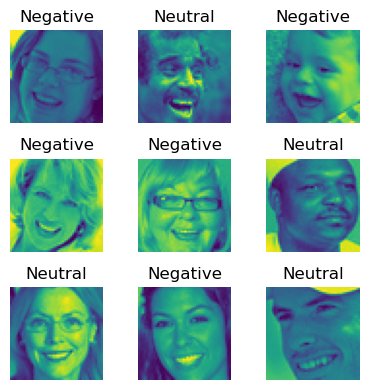

In [145]:
import cv2
import matplotlib.image as mpimg

cols = 3
rows = 3
total = rows * cols
plt.figure(figsize=(4,4))
for i, (idx, row) in enumerate(image_df.head(total).iterrows(),1):
    img = mpimg.imread(row['image_path'])
    plt.subplot(rows, cols, i)
    plt.imshow(img)
    plt.title(f"{row['label']}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [109]:
# labels = ["Positive", "Negative", "Neutral", "Highly Positive"]
# sampled_data = []

# for label in labels:
#     sampled_data.append(image_df[image_df["label"] == label].sample(
#         n=min(100, len(image_df[image_df["label"] == label])), 
#         random_state=42
#     ))

# image_df = pd.concat(sampled_data).sample(frac=1, random_state=42).reset_index(drop=True)

# image_df

In [146]:
label_mapping = {
    'Negative': 0,
    'Positive': 1,
    'Highly Positive':2,
    'Neutral':3,
}

image_df['label'] = image_df['label'].map(label_mapping)
image_df

,image_path,label
0,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,0
1,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,3
3,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,0
4,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,0
7,D:\multimodal\FER-2013\FER-2013\train\happy\Tr...,0
...,...,...
21444,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...,2
21453,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...,1
21455,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...,1
21460,D:\multimodal\FER-2013\FER-2013\test\fear\Publ...,2


In [147]:
import torch
print(torch.__version__)
print(torch.Tensor)  

2.6.0+cu118
<class 'torch.Tensor'>


In [148]:
from datasets import Dataset, DatasetDict

dataset = Dataset.from_dict(image_df)
dataset

Dataset({
    features: ['image_path', 'label'],
    num_rows: 21472
})

In [149]:
from sklearn.model_selection import train_test_split
dataset= dataset.train_test_split(test_size=0.20, seed=42)
dataset

DatasetDict({
    train: Dataset({
        features: ['image_path', 'label'],
        num_rows: 17177
    })
    test: Dataset({
        features: ['image_path', 'label'],
        num_rows: 4295
    })
})

In [150]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import Trainer, TrainingArguments

def compute_metrics(p):
    preds = p.predictions.argmax(axis=-1)
    labels = p.label_ids
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted', zero_division=1)
    accuracy = accuracy_score(labels, preds)
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [152]:
import torch
import warnings
warnings.filterwarnings('ignore')
from transformers import ViTForImageClassification, ViTImageProcessor, Trainer, TrainingArguments
# model_name = "motheecreator/vit-Facial-Expression-Recognition"
model_name="google/vit-base-patch16-224"
model = ViTForImageClassification.from_pretrained(model_name,num_labels=4,ignore_mismatched_sizes=True)
processor = ViTImageProcessor.from_pretrained(model_name)

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([4]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

In [ ]:
from PIL import Image
import numpy as np
from transformers import ViTImageProcessor
import albumentations as A
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

import albumentations as A

transform = A.Compose([
    A.Resize(48,48),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5), 
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.RandomScale(scale_limit=0.2, p=0.5), 
    A.ElasticTransform(alpha=1.0, sigma=50.0, alpha_affine=50.0, p=0.5),
    A.GaussianBlur(blur_limit=(3, 7), p=0.5),
    A.MotionBlur(blur_limit=7, p=0.5),
    A.RandomGamma(gamma_limit=(80, 120), p=0.5),
    A.RandomFog(fog_coef_lower=0.3, fog_coef_upper=0.5, alpha_coef=0.1, p=0.5),
    A.CoarseDropout(max_holes=8, max_height=16, max_width=16, min_holes=4, p=0.5),
    A.Perspective(shift_limit=0.5, scale=(0.05, 0.1), p=0.5),
    A.ChannelShuffle(p=0.5),
    A.Affine(shear=(0.1, 0.2), p=0.5),
    A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=30, val_shift_limit=20, p=0.5),
    A.RGBShift(r_shift_limit=20, g_shift_limit=20, b_shift_limit=20, p=0.5),
])

def preprocess_function(examples):
    images = [Image.open(image_path) for image_path in examples['image_path']]
    images = [np.array(image.convert('RGB')) if image.mode != 'RGB' else np.array(image) for image in images]
    augmented_images = [transform(image=image)['image'] for image in images]

    processor = ViTImageProcessor.from_pretrained("motheecreator/vit-Facial-Expression-Recognition")
    processed_images = processor(images=augmented_images, return_tensors="pt")

    labels = examples['label']
    processed_images['label'] = labels

    return processed_images

processed_dataset = dataset.map(preprocess_function, batched=True,batch_size=2,remove_columns=['image_path'],load_from_cache_file=False)

Map:   0%|          | 0/17177 [00:00<?, ? examples/s]

In [ ]:
test_dataset=processed_dataset['test']
test_dataset

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
device

In [ ]:
import torch, transformers, accelerate
print(f"PyTorch: {torch.__version__}")  # Should be 2.2.1+cu121
print(f"Transformers: {transformers.__version__}")  # Should be 4.51.3 or newer
print(f"Accelerate: {accelerate.__version__}")  # Should be 1.6.0 or newer
print(f"CUDA available: {torch.cuda.is_available()}")  # Should be True

In [ ]:
from transformers import TrainingArguments

args = TrainingArguments(
    output_dir="./test-output",
    per_device_train_batch_size=8,
    num_train_epochs=1
)
print("Success! TrainingArguments created.")

In [ ]:
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback, DefaultDataCollator
import torch
from torch.optim import AdamW
import warnings

warnings.filterwarnings('ignore')

model.config.hidden_dropout_prob = 0.5

optimizer = AdamW(model.parameters(), weight_decay=0.3, eps=1e-8, betas=(0.9, 0.999))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

collate_fn = DefaultDataCollator()

training_args = TrainingArguments(
    output_dir="./vit-emotion",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    per_device_train_batch_size=64,
    per_device_eval_batch_size=32,
    num_train_epochs=10,
    learning_rate=5e-5,
    logging_dir="./logs",
    logging_steps=100,
    save_total_limit=3,
    report_to="none",
    warmup_steps=500,
    lr_scheduler_type='linear',
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_steps=1000,
    eval_steps=500,
    eval_accumulation_steps=2,
    gradient_accumulation_steps=2,
    fp16=True,
    dataloader_num_workers=4,
    dataloader_pin_memory=True,
    dataloader_drop_last=True,
    dataloader_persistent_workers=True,
    max_grad_norm=1.0,
    label_smoothing_factor=0.1
)

callbacks = [EarlyStoppingCallback(early_stopping_patience=3, early_stopping_threshold=0.01)]

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=processed_dataset["train"],
    eval_dataset=processed_dataset["test"],
    tokenizer=processor,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    callbacks=callbacks,
    optimizers=(optimizer, None)
)
trainer.train()

In [ ]:
trainer.evaluate()

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
predictions, labels, _ = trainer.predict(test_dataset)
predicted_labels = np.argmax(predictions, axis=1)
predicted_labels

In [ ]:
cm=confusion_matrix(labels,predicted_labels)
cm

In [ ]:
disp = ConfusionMatrixDisplay(cm,display_labels=["Negative","Positive","Highly Positive","Neutral"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report
report = classification_report(labels, predicted_labels, labels=[0,1,2,3], target_names=["Negative","Positive","Highly Positive","Neutral"])
print(report)

In [ ]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=["Negative","Positive","Highly Positive","Neutral"], yticklabels=["Negative","Positive","Highly Positive","Neutral"])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Normalized Confusion Matrix')
plt.show()

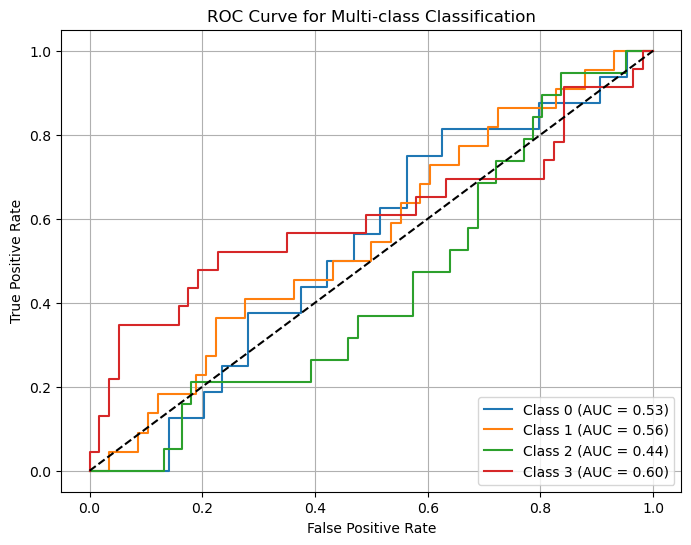

<Figure size 640x480 with 0 Axes>

In [98]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

predicted_probs = predictions

true_labels_binarized = label_binarize(labels, classes=[0, 1, 2, 3])

plt.figure(figsize=(8, 6))

for i in range(true_labels_binarized.shape[1]):
    fpr, tpr, thresholds = roc_curve(true_labels_binarized[:, i], predicted_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='black', linestyle='--')


plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Multi-class Classification')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

plt.savefig('roc_curve.png', dpi=300)
plt.show()

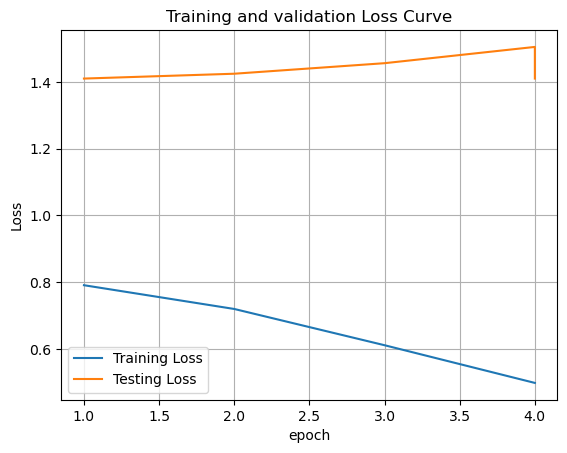

In [99]:
import matplotlib.pyplot as plt

trainer_state = trainer.state

train_loss = [log['loss'] for log in trainer_state.log_history if 'loss' in log]
train_steps = [log['epoch'] for log in trainer_state.log_history if 'loss' in log]

eval_loss = [log['eval_loss'] for log in trainer_state.log_history if 'eval_loss' in log]
eval_steps = [log['epoch'] for log in trainer_state.log_history if 'eval_loss' in log]

plt.plot(train_steps, train_loss, label="Training Loss")

plt.plot(eval_steps, eval_loss, label="Testing Loss")

plt.xlabel("epoch")
plt.ylabel("Loss")
plt.title("Training and validation Loss Curve")
plt.legend()
plt.grid()
plt.show()

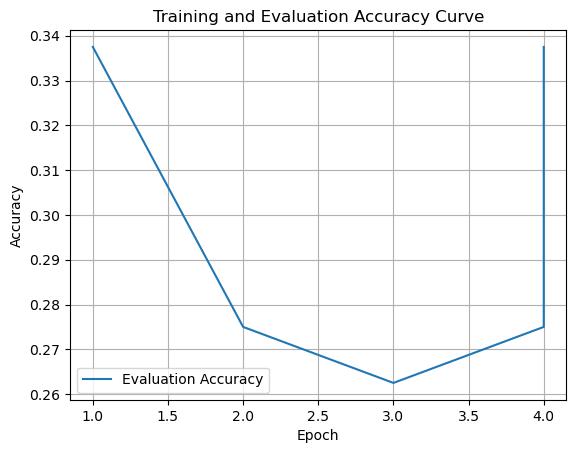

In [100]:
import matplotlib.pyplot as plt
trainer_state = trainer.state
train_accuracy = [log['train_accuracy'] for log in trainer_state.log_history if 'train_accuracy' in log]
train_epoch = [log['epoch'] for log in trainer_state.log_history if 'train_accuracy' in log]

eval_accuracy = [log['eval_accuracy'] for log in trainer_state.log_history if 'eval_accuracy' in log]
eval_epoch = [log['epoch'] for log in trainer_state.log_history if 'eval_accuracy' in log]

if train_accuracy:
    plt.plot(train_epoch,train_accuracy, label="Training Accuracy")

plt.plot(eval_epoch, eval_accuracy, label="Evaluation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Evaluation Accuracy Curve")
plt.legend()
plt.grid()
plt.show()